# Saturation analysis: pathway coverage vs K size

**Environment:** `clamp-analyses`

For ARCHS4 data at various sample coverage levels, plots pathway coverage (y-axis) against K: the number of latent variables: where K is taken as 5%, 10%, 25%, 50%, 75%, 100% of K_100 (the CLAMP K from the 100% coverage model at seed 1). Each line is one data coverage level; each boxplot shows the distribution over 3 seeds.

Source: `07_saturation` outputs.


## Load libraries

In [1]:
library(here)
library(ggplot2)
library(dplyr)

source(here("config.R"))

base_output_dir <- config$ARCHS4$DATASET_FOLDER

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Helper: GetCLAMPPathwayCoverage

In [2]:
GetCLAMPPathwayCoverage <- function(clamp.results, fdr.cutoff = 0.05, auc.cutoff = 0.6) {
  summary.df     <- clamp.results$summary
  input.pathways <- colnames(clamp.results$C)
  num.lvs        <- ncol(clamp.results$U)

  sig.df       <- summary.df[summary.df$FDR < fdr.cutoff & summary.df$AUC > auc.cutoff, ]
  sig.pathways <- unique(sig.df$pathway)
  sig.lvs      <- unique(sig.df$LV)

  list(
    pathway           = length(sig.pathways) / length(input.pathways),
    lv                = length(sig.lvs) / num.lvs,
    sig.pathway.by.lv = length(sig.pathways) / num.lvs
  )
}

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title       = element_text(size = 24, colour = "black"),
      axis.title.y     = element_text(margin = margin(r = 18)),
      axis.text        = element_text(size = 18, colour = "black"),
      axis.line        = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks       = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor = element_blank(),
      legend.position  = "right",
      strip.background = element_blank(),
      strip.text       = element_text(face = "bold", size = 18),
      plot.margin      = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

## Define model grid

In [3]:
k_fracs <- c(0.05, 0.10, 0.25, 0.50, 0.75, 1.00)

pct_to_subdir <- c(
  "1"   = "00_bp_coverage_hall_rs_01",
  "5"   = "01_bp_coverage_hall_rs_05",
  "10"  = "02_bp_coverage_hall_rs_10",
  "25"  = "03_bp_coverage_hall_rs_25",
  "50"  = "04_bp_coverage_hall_rs_50",
  "75"  = "05_bp_coverage_hall_rs_75",
  "100" = "06_bp_coverage_hall_rs_100"
)

get_06_model_dir <- function(pct, seed_idx) {
  file.path(base_output_dir, "06_bp_coverage_rshall",
            pct_to_subdir[as.character(pct)],
            sprintf("hall_coverage_rs%d_seed_%d", pct, seed_idx))
}

K_100    <- readRDS(file.path(get_06_model_dir(100L, 1L), "CLAMP_K.rds"))
k_values <- sort(unique(as.integer(round(k_fracs * K_100))))
message("K_100 = ", K_100, " | k_values = ", paste(k_values, collapse = ", "))

data_coverages <- c(1L, 5L, 10L, 25L)  # expand to c(1L,5L,10L,25L,50L,75L,100L) as jobs complete
seed_indices   <- 1:3

model_grid <- expand.grid(data_pct = data_coverages, k_val = k_values,
                           seed_idx = seed_indices, stringsAsFactors = FALSE)

get_model_path <- function(data_pct, k_val, seed_idx) {
  file.path(base_output_dir, "07_saturation",
            sprintf("hall_saturation_rs%d_k%d_seed_%d", data_pct, k_val, seed_idx),
            "CLAMPfull_hall.rds")
}

message("Model grid: ", nrow(model_grid), " combinations")

K_100 = 1728 | k_values = 86, 173, 432, 864, 1296, 1728

Model grid: 72 combinations



## Load results (FDR 0.1, AUC 0.6)

In [4]:
results <- lapply(seq_len(nrow(model_grid)), function(i) {
  data_pct <- model_grid$data_pct[i]
  k_val    <- model_grid$k_val[i]
  seed_idx <- model_grid$seed_idx[i]

  model_path <- get_model_path(data_pct, k_val, seed_idx)

  if (!file.exists(model_path)) {
    message("Not found: ", model_path)
    return(NULL)
  }

  model   <- readRDS(model_path)
  cov     <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.1, auc.cutoff = 0.6)

  data.frame(
    data_pct       = data_pct,
    k_val          = k_val,
    seed_idx       = seed_idx,
    CLAMP_K        = ncol(model$U),
    n_samples      = ncol(model$B),
    prop_pathway   = cov$pathway,
    prop_lv        = cov$lv,
    stringsAsFactors = FALSE
  )
})

results_df <- do.call(rbind, Filter(Negate(is.null), results))
rownames(results_df) <- NULL

results_df <- results_df %>%
  dplyr::arrange(data_pct, seed_idx, k_val)

message("Loaded ", nrow(results_df), " combinations")
print(results_df)

Not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/07_saturation/hall_saturation_rs25_k1296_seed_1/CLAMPfull_hall.rds

Not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/07_saturation/hall_saturation_rs1_k1728_seed_1/CLAMPfull_hall.rds

Not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/07_saturation/hall_saturation_rs25_k1728_seed_1/CLAMPfull_hall.rds

Not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/07_saturation/hall_saturation_rs1_k86_seed_2/CLAMPfull_hall.rds

Not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/07_saturation/hall_saturation_rs25_k86_seed_2/CLAMPfull_hall.rds

Not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/07_saturation/hall_saturation_rs1_k173_seed_2/CLAMPfull_hall.rds

Not found: /home/msubirana/Documents

   data_pct k_val seed_idx CLAMP_K n_samples prop_pathway   prop_lv
1         1    86        1      86      6056    0.1415510 0.9418605
2         1   173        1     173      6056    0.2065696 0.9017341
3         1   432        1     432      6056    0.2980020 0.8356481
4         1   864        1     864      6056    0.3521842 0.7615741
5         1  1296        1    1296      6056    0.3860481 0.7052469
6         5    86        1      86     30281    0.1398578 0.9651163
7         5   173        1     173     30281    0.2055537 0.9364162
8         5   432        1     432     30281    0.2929225 0.8541667
9         5   864        1     864     30281    0.3450728 0.7118056
10        5  1296        1    1296     30281    0.3853708 0.6041667
11        5  1728        1    1728     30281    0.3874026 0.5329861
12        5    86        2      86     30281    0.1405350 0.9767442
13        5   173        2     173     30281    0.2079241 0.9248555
14        5   432        2     432     30281    

## Plot: pathway coverage vs K (saturation curves)

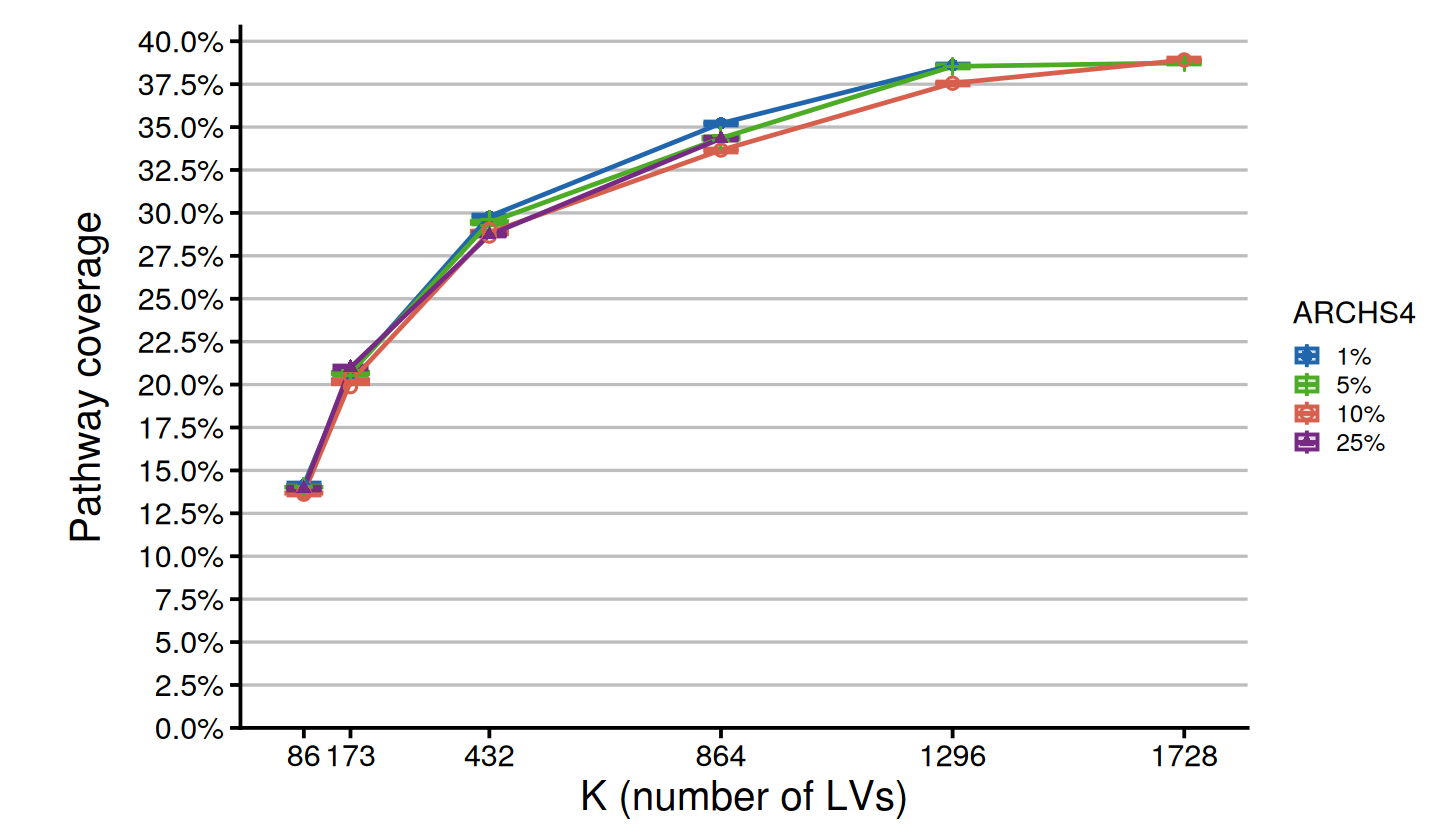

In [5]:
options(repr.plot.width = 12, repr.plot.height = 7)

coverage_colors <- c(
  "1%"   = "#2166AC",
  "5%"   = "#4DAC26",
  "10%"  = "#D6604D",
  "25%"  = "#762A83",
  "50%"  = "#E08214",
  "75%"  = "#01665E",
  "100%" = "#000000"
)
coverage_shapes <- c("1%"=16, "5%"=3, "10%"=1, "25%"=17, "50%"=15, "75%"=8, "100%"=18)

avail_levels <- paste0(sort(unique(results_df$data_pct)), "%")

plot_df <- results_df %>%
  dplyr::mutate(data_label = factor(paste0(data_pct, "%"),
                                    levels = paste0(c(1, 5, 10, 25, 50, 75, 100), "%")))

line_df <- plot_df %>%
  dplyr::group_by(data_pct, k_val, data_label) %>%
  dplyr::summarise(y = median(prop_pathway), .groups = "drop") %>%
  dplyr::arrange(data_label, k_val)

box_width <- diff(range(k_values)) * 0.04

p <- ggplot(plot_df, aes(x = k_val, y = prop_pathway,
                          colour = data_label, fill = data_label)) +
  geom_boxplot(aes(group = interaction(data_label, factor(k_val))),
               alpha = 0.2, outlier.shape = NA, width = box_width,
               position = "identity") +
  geom_line(data = line_df,
            aes(x = k_val, y = y, group = data_label), linewidth = 1.0) +
  geom_point(aes(shape = data_label), size = 2.5, stroke = 1.0) +
  scale_x_continuous(breaks = k_values) +
  scale_colour_manual(values = coverage_colors, name = "ARCHS4",
                      limits = avail_levels) +
  scale_fill_manual(values   = coverage_colors, name = "ARCHS4",
                    limits = avail_levels) +
  scale_shape_manual(values  = coverage_shapes, name = "ARCHS4",
                     limits = avail_levels) +
  scale_y_continuous(labels  = scales::percent_format(accuracy = 0.1),
                     breaks  = seq(0, 1, by = 0.025),
                     limits  = c(0, NA),
                     expand  = expansion(mult = c(0, 0.05))) +
  labs(x = "K (number of LVs)", y = "Pathway coverage") +
  theme_ng()

p
